In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pipeline as pipeline
import copy
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [3]:
import os

def list_all_csv_files(dir_path):
    """
    주어진 dir_path 아래의 모든 하위 디렉토리를 포함하여
    .csv 확장자를 가진 파일의 전체 경로를 리스트로 반환합니다.
    """
    csv_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

dir_path = './data_ready/input_data'
csv_files = list_all_csv_files(dir_path)
csv_files


['./data_ready/input_data/NR/joined_input_data_NR_Early.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-dry.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Intermediate.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-wet.csv',
 './data_ready/input_data/Eth/African/joined_input_data_African_ancestry_Late-dry.csv',
 './data_ready/input_data/Eth/African/joined_input_data_African_ancestry_Early to intermediate.csv',
 './data_ready/input_data/Eth/African/joined_input_data_African_ancestry_Intermediate.csv',
 './data_ready/input_data/Eth/African/joined_input_data_African_ancestry_Late-wet.csv',
 './data_ready/input_data/Eth/European/joined_input_data_European_ancestry_Late-dry.csv',
 './data_ready/input_data/Eth/European/joined_input_data_European_ancestry_Early.csv',
 './data_ready/input_data/Eth/European/joined_input_data_European_ancestry_Intermediate.csv',
 './data_ready/input_data/Eth/European/joined_input_data_European_ancestry_Late-wet.csv',
 './data_

In [4]:
basedir = '/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params'

input_data_path = csv_files[8]
output_template_path = f'{basedir}/output_template.csv'
detailed_pop_path=f'{basedir}/pop_detailed.csv'
parameters_path = f'{basedir}/parameters.jsonc'
hierarchy_path = f'{basedir}/hierarchy.json' 
input_data_path 

'./data_ready/input_data/Eth/European/joined_input_data_European_ancestry_Late-dry.csv'

In [5]:
pm_model = pipeline.initiliaze_pipeline(
    input_data_path=input_data_path,
    output_template_path=output_template_path,
    parameters_path=parameters_path,
    hierarchy_path=hierarchy_path,
    detailed_pop_path=detailed_pop_path,
    verbose=True
)

number of rows: 114
number of unique location_id: 12
number of nodes: 233
number of edges: 232


In [6]:
rate_types = ['beta_binom', 'binom', 'neg_binom', 'poisson', 'log_normal', 'normal', 'offset_log_normal']
rate_type = rate_types[2]
# 모델 객체 복제
pm_model_copy = copy.deepcopy(pm_model)

# 필요하다면 shared_data 같은 dict도 별도로 복사
pm_model_copy.shared_data = copy.deepcopy(pm_model.shared_data)

pipeline.generate_pymc_objects(pm_model_copy, rate_type=rate_type, include_covariates=True)

Standard errors replaced: 0
Effective sample sizes filled: 0


In [7]:
map_estimate = pipeline.return_map_estimate(pm_model=pm_model_copy, verbose=True)

INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


In [8]:
idata = pipeline.return_idata(pm_model     = pm_model_copy, 
                            map_estimate   = map_estimate, 
                            draws          = 1000,
                            tune           = 500,
                            chains         = 8,
                            cores          = 4,
                            target_accept  = 0.9,
                            max_treedepth  = 10,
                            use_advi       = False,
                            use_metropolis = True,
                            verbose=True
                            ) 
# 198.3초 소요

INFO:pipeline:  ▶ Metropolis 샘플링 수행 중...
Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO

Sampling 8 chains for 500 tune and 1_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.
INFO:pymc:Sampling 8 chains for 500 tune and 1_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
INFO:pipeline:[asr] 전체 소요 시간: 67.3초


In [19]:
import numpy as np
import arviz as az

# 1) posterior 변수 이름 중에 'beta' 포함된 것만 추출
beta_vars = [var for var in idata.posterior.data_vars if 'beta' in var]
print("Found beta variables:", beta_vars)

# 2) NumPy로 직접 mean 계산 (chain, draw 차원 평균)
mean_beta = {
    var: idata.posterior[var].values.mean(axis=(0, 1))
    for var in beta_vars
}

# 결과 출력
for var, m in mean_beta.items():
    print(f"{var} mean:\n{m}\n")


# —— 또는 —— #

# 3) ArviZ의 summary로 한 번에 보기
summary_beta = az.summary(idata, var_names=beta_vars)
print(summary_beta[['mean']])

# 2) 90% HDI로 변경하고 싶을 때
summary_beta_90 = az.summary(
    idata,
    var_names=beta_vars,
    stat_focus="mean",
    hdi_prob=0.90,          # 90% HDI
    round_to=4
)
print(summary_beta_90[['mean', 'hdi_5%', 'hdi_95%']])



Found beta variables: ['beta_p_x_sex', 'beta_p_x_lpa', 'beta_p_x_sev', 'beta_p_x_sdi']
beta_p_x_sex mean:
-0.0005772061533492896

beta_p_x_lpa mean:
0.014894536325003238

beta_p_x_sev mean:
0.024896061614510183

beta_p_x_sdi mean:
0.0

               mean
beta_p_x_sex -0.001
beta_p_x_lpa  0.015
beta_p_x_sev  0.025
beta_p_x_sdi  0.000
                mean  hdi_5%  hdi_95%
beta_p_x_sex -0.0006 -0.0145   0.0104
beta_p_x_lpa  0.0149  0.0001   0.0293
beta_p_x_sev  0.0249  0.0002   0.0471
beta_p_x_sdi  0.0000  0.0000   0.0000


/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [18]:
summary_df = pipeline.return_rhat(idata)

Total vars:    688
R-hat > 1.01:  566
R-hat <= 1.01:  62
R-hat missing: 60
<xarray.Dataset> Size: 10kB
Dimensions:               (knot: 9, p_pred_p_dim_0: 114, age: 101,
                           cum_sum_mu_p_dim_0: 101, mu_interval_p_dim_0: 114,
                           pi_p_dim_0: 114)
Coordinates:
  * knot                  (knot) float64 72B 0.0 30.0 40.0 ... 80.0 90.0 100.0
  * p_pred_p_dim_0        (p_pred_p_dim_0) int64 912B 0 1 2 3 ... 111 112 113
  * age                   (age) float64 808B 0.0 1.0 2.0 3.0 ... 98.0 99.0 100.0
  * cum_sum_mu_p_dim_0    (cum_sum_mu_p_dim_0) int64 808B 0 1 2 3 ... 98 99 100
  * mu_interval_p_dim_0   (mu_interval_p_dim_0) int64 912B 0 1 2 ... 111 112 113
  * pi_p_dim_0            (pi_p_dim_0) int64 912B 0 1 2 3 4 ... 110 111 112 113
Data variables: (12/41)
    gamma_p               (knot) float64 72B 1.003 1.004 1.123 ... 1.101 1.088
    sigma_alpha_p_0_z     float64 8B 1.001
    sigma_alpha_p_1_z     float64 8B 1.004
    sigma_alpha_p_2_z     f

In [10]:
pred = pipeline.predict_for(pm_model            = pm_model_copy,
                            idata               = idata, 
                            root_area           = 'Global',
                            root_sex            = 'Both',
                            root_year           = 'all',
                            location_id                = 1,
                            sex_name                 = 'Both',
                            year_id                = 2021,
                            population_weighted = True,
                            lower               = 0.0,
                            upper               = 1.0,
                            include_covariates  = True,
                            return_scalar       = False
                            )

In [70]:
import pandas as pd
import numpy as np

# === 1) pred 불러오기 ===
# 예: pred = pipeline.predict_for(...)
# pred.shape == (n_samples, n_ages)  # 여기서는 (32000, 101)

# === 2) 통계량 계산 ===
mean_vals    = pred.mean(axis=0)
lower_vals   = np.percentile(pred,  2.5, axis=0)
upper_vals   = np.percentile(pred, 97.5, axis=0)

# === 3) DataFrame 생성 ===
ages = np.arange(pred.shape[1])  # 0,1,2,...,100

df = pd.DataFrame({
    'mean'     : mean_vals,
    'lower_ci' : lower_vals,
    'upper_ci' : upper_vals
}, index=ages)

df.index.name = 'age'

# === 4) CSV로 저장 ===
out_path = f'prevalence_2021_2.csv'
df.to_csv(out_path)
print(f"Saved summary to {out_path}")


Saved summary to prevalence_2021_2.csv


In [48]:
results = pipeline.world_predict(
    pm_model_copy,
    idata,
    years=list(range(1990, 2022)),
    output_csv_path=f'1990_2021_all_regions.csv'
)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
[world_predict] Saved 7232 rows to '1990_2021_all_regions.csv'


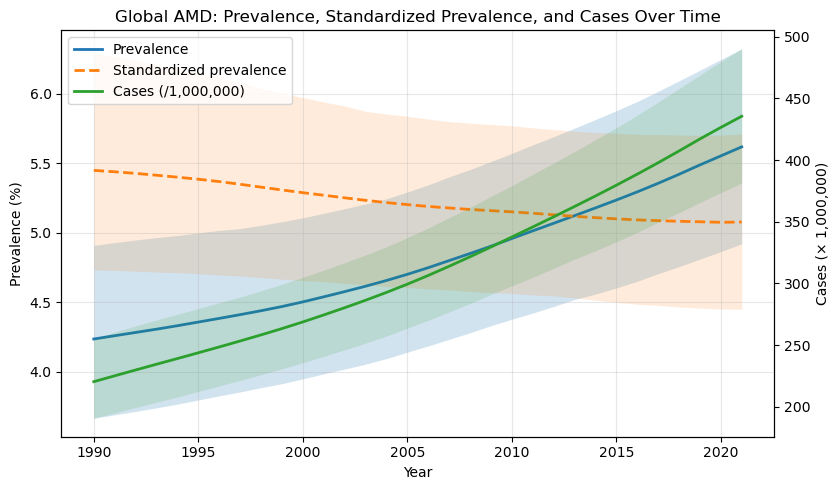

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_global_triple_trend(
    df: pd.DataFrame,
    save_path: str = "global_triple_trend.png",
    percent=True,
    cases_unit=1e6
):
    gdf = df[df["level"] == 0].copy()

    counts = gdf["year"].value_counts()
    duplicates = counts[counts > 1]
    if not duplicates.empty:
        raise ValueError(f"Global rows have duplicate years: {duplicates.index.tolist()}")

    required_cols = [
        "year",
        "mean_prev","lower_prev","upper_prev",
        "mean_prev_std","lower_prev_std","upper_prev_std",
        "mean_cases","lower_cases","upper_cases"
    ]
    missing = [c for c in required_cols if c not in gdf.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    agg = gdf.sort_values("year")[required_cols].reset_index(drop=True)

    scale = 100.0 if percent else 1.0
    years = agg["year"].to_numpy()

    y_prev      = agg["mean_prev"].to_numpy() * scale
    y_prev_lo   = agg["lower_prev"].to_numpy() * scale
    y_prev_hi   = agg["upper_prev"].to_numpy() * scale

    y_prev_std    = agg["mean_prev_std"].to_numpy() * scale
    y_prev_std_lo = agg["lower_prev_std"].to_numpy() * scale
    y_prev_std_hi = agg["upper_prev_std"].to_numpy() * scale

    y_cases      = agg["mean_cases"].to_numpy() / cases_unit
    y_cases_lo   = agg["lower_cases"].to_numpy() / cases_unit
    y_cases_hi   = agg["upper_cases"].to_numpy() / cases_unit

    # 색상 팔레트에서 3가지 색 선택
    colors = plt.get_cmap("tab10").colors
    c1, c2, c3 = colors[0], colors[1], colors[2]

    fig, ax = plt.subplots(figsize=(8.5, 5))

    # 유병률
    line1, = ax.plot(years, y_prev, linewidth=2, color=c1, label="Prevalence")
    ax.fill_between(years, y_prev_lo, y_prev_hi, alpha=0.2, linewidth=0, color=c1)

    # 표준화 유병률
    line2, = ax.plot(years, y_prev_std, linewidth=2, linestyle="--", color=c2, label="Standardized prevalence")
    ax.fill_between(years, y_prev_std_lo, y_prev_std_hi, alpha=0.15, linewidth=0, color=c2)

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Prevalence ({'%' if percent else 'per 1'})")
    ax.grid(True, alpha=0.3)

    # 절대 환자수
    ax2 = ax.twinx()
    line3, = ax2.plot(years, y_cases, linewidth=2, color=c3, label=f"Cases (/{int(cases_unit):,})")
    ax2.fill_between(years, y_cases_lo, y_cases_hi, alpha=0.15, linewidth=0, color=c3)
    ax2.set_ylabel(f"Cases (× {int(cases_unit):,})")

    # 범례
    lines = [line1, line2, line3]
    labels = [ln.get_label() for ln in lines]
    ax.legend(lines, labels, loc="upper left")

    plt.title("Global AMD: Prevalence, Standardized Prevalence, and Cases Over Time")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()



# 사용 예시
# df = world_predict(...)
plot_global_triple_trend(results, "global_prev_trend.png")


/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:602: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


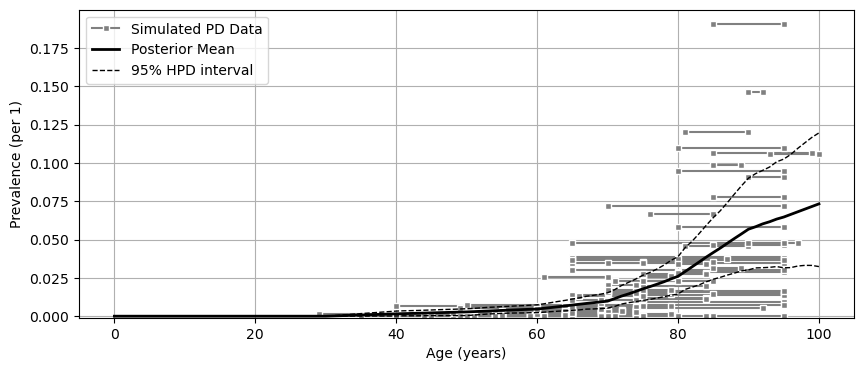

In [11]:
pipeline.visualize_pred(pred, pm_model_copy.shared_data["data"])

In [23]:
# 3) (간단) pickle로 저장
import pickle
pkl_path = f"./idata_2021.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(idata, f)
print(f"Pickled InferenceData to {pkl_path}")

Pickled InferenceData to ./idata_2021.pkl


[time_trend] Saved CSV to 'data_ready/params/time_trend.csv'


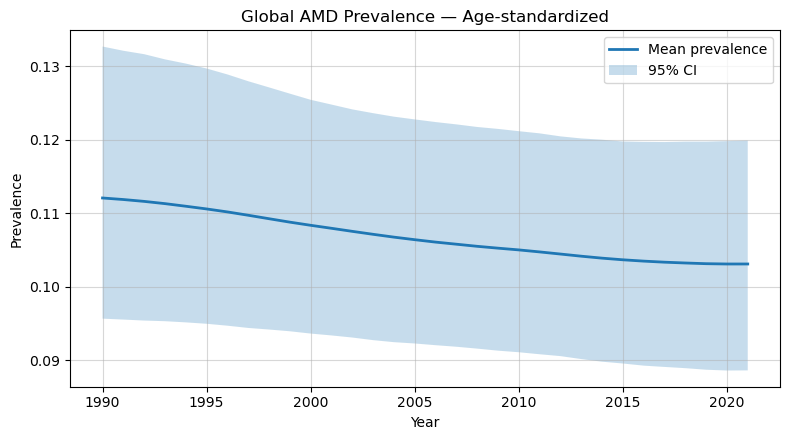

,year_id,mean_prev,lower_95,upper_95
0,1990,0.112071,0.095662,0.132667
1,1991,0.111861,0.095536,0.132093
2,1992,0.111608,0.095402,0.131627
3,1993,0.111303,0.095314,0.130922
4,1994,0.110949,0.095155,0.130351
5,1995,0.110581,0.094963,0.129680
6,1996,0.110175,0.094704,0.128872
7,1997,0.109723,0.094397,0.127949
8,1998,0.109251,0.094183,0.127110
9,1999,0.108785,0.093945,0.126261


In [23]:
years_of_interest = list(range(1990, 2022))
ages_of_interest = list(range(30, 101))
pop_glo_yrs_age_path = 'data_ready/params/pop_glo_yrs_ages.csv'
output_csv_path = 'data_ready/params/time_trend.csv'
pipeline.time_trend(
    pm_model=pm_model_copy,
    idata=idata,
    years_of_interest=years_of_interest,
    ages_of_interest=ages_of_interest,
    pop_glo_yrs_age_path=pop_glo_yrs_age_path,
    output_csv_path=output_csv_path,
    is_std_pop=True,
    is_plot=True
)
